# Per-round resolution stats

For each scrape round, count how many `(country, language)` pairs have been resolved (i.e. `parse_speaker_count` returned a non-None integer for at least one row in that round or any earlier round).

A pair counts as **resolved at round N** if any row in rounds 1..N produced a parseable integer. A pair is **unresolved at round N** if it has been *attempted* in rounds 1..N but has not yet produced a parseable integer.

In [5]:
import csv
import re
from pathlib import Path

import pandas as pd

from low.scraper.aggregate import parse_speaker_count

DATA_DIR = Path('../scraper-data')
RESPONSE_COLUMN = 'llm_response'
RESULTS_RE = re.compile(r'^prompts(\d+)([a-z]*)_results_.+\.csv$')

In [6]:
# Group result files by round number.
files_by_round: dict[int, list[Path]] = {}
for p in sorted(DATA_DIR.iterdir()):
    m = RESULTS_RE.match(p.name)
    if not m:
        continue
    files_by_round.setdefault(int(m.group(1)), []).append(p)

files_by_round

{1: [PosixPath('../scraper-data/prompts1a_results_google_gemini-3.1-flash-lite.csv'),
  PosixPath('../scraper-data/prompts1b_results_google_gemini-3.1-flash-lite.csv')],
 2: [PosixPath('../scraper-data/prompts2a_results_google_gemini-3.1-flash-lite.csv')],
 3: [PosixPath('../scraper-data/prompts3a_results_google_gemini-3.1-flash-lite.csv')],
 4: [PosixPath('../scraper-data/prompts4a_results_google_gemini-3.1-flash-lite.csv')],
 5: [PosixPath('../scraper-data/prompts5a_results_google_gemini-3.1-flash-lite.csv')],
 6: [PosixPath('../scraper-data/prompts6a_results_google_gemini-3.1-flash-lite.csv')]}

In [7]:
# Walk rounds in order, accumulating tried + resolved pair sets.
tried: set[tuple[str, str]] = set()
resolved: set[tuple[str, str]] = set()
rows = []

for rnd in sorted(files_by_round):
    for path in files_by_round[rnd]:
        with path.open('r', newline='', encoding='utf-8') as f:
            reader = csv.DictReader(f)
            for row in reader:
                key = (row['country'], row['language'])
                tried.add(key)
                if parse_speaker_count(row.get(RESPONSE_COLUMN, '')) is not None:
                    resolved.add(key)
    resolved_count = len(resolved)
    unresolved_count = len(tried) - resolved_count
    total = len(tried)
    rows.append({
        'round': rnd,
        'resolved_count': resolved_count,
        'unresolved_count': unresolved_count,
        'resolved_rate': resolved_count / total if total else 0.0,
    })

df = pd.DataFrame(rows)
df.round(2)

,round,resolved_count,unresolved_count,resolved_rate
0,1,641,1798,0.26
1,2,889,1550,0.36
2,3,1050,1389,0.43
3,4,1197,1242,0.49
4,5,1293,1146,0.53
5,6,1352,1087,0.55


Text(0.5, 0, 'Round')

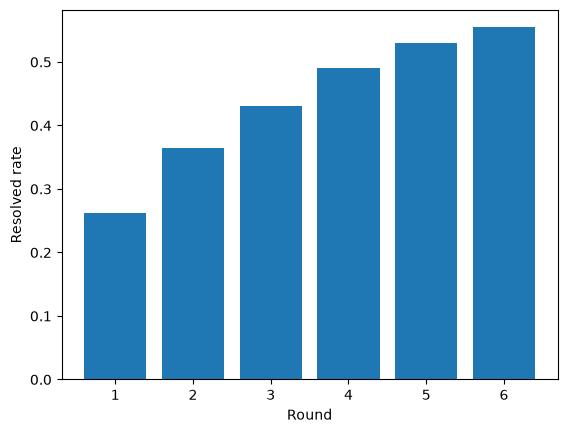

In [8]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
ax.bar(df['round'], df.resolved_rate)
ax.set_ylabel("Resolved rate")
ax.set_xlabel("Round")